In [4]:
!pip install pyreadstat

import pyreadstat
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings("ignore")

W1 = "/content/21600-0001-Data.dta"
W2 = "/content/21600-0005-Data.dta"


def drop_bad(s, bad_vals):
    return s.where(~s.isin(bad_vals))


def cronbach(data):
    d = data.dropna()
    n = d.shape[1]
    return (n / (n - 1)) * (1 - d.var(ddof=1).sum() / d.sum(axis=1).var(ddof=1))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.5 MB/s eta 0:00:00


In [6]:
# 1. Variables

df1, meta1 = pyreadstat.read_dta(W1)
df2, meta2 = pyreadstat.read_dta(W2)
df1.columns = [c.upper() for c in df1.columns]
df2.columns = [c.upper() for c in df2.columns]

# Depression
fs_cols = [f"H1FS{i}" for i in range(1, 20)]
for c in fs_cols:
    df1[c] = drop_bad(df1[c], [6, 7, 8])

# Positive-affect items (4, 8, 11, 15): reverse-code 0<->3
for i in [4, 8, 11, 15]:
    df1[f"H1FS{i}"] = 3 - df1[f"H1FS{i}"]

df1["dep_w1"] = df1[fs_cols].mean(axis=1, skipna=True)
df1.loc[df1[fs_cols].notna().sum(axis=1) < 14, "dep_w1"] = np.nan

# Baseline Math GPA at Wave I
df1["H1ED12"] = drop_bad(df1["H1ED12"], [5, 6, 96, 97, 98])
df1["gpa_w1"] = 5 - df1["H1ED12"]

# Gender: 0=Male, 1=Female
df1["BIO_SEX"] = drop_bad(df1["BIO_SEX"], [6])
df1["gender"] = np.where(df1["BIO_SEX"] == 2, 1.0,
                np.where(df1["BIO_SEX"] == 1, 0.0, np.nan))

# SES - mother education
df1["H1RM1"] = drop_bad(df1["H1RM1"], [96, 97, 98, 10, 11, 12])
df1["ses_w1"] = df1["H1RM1"].where(df1["H1RM1"] <= 9)

# Self-Efficacy
for c in ["H1SE1", "H1SE2", "H1SE3"]:
    df1[c] = drop_bad(df1[c], [6, 96, 97, 98, 99])

df1["H1SE4"] = drop_bad(df1["H1SE4"], [96, 98])
df1["H1SE4_r"] = (7 - df1["H1SE4"]).clip(1, 5)

se_cols = ["H1SE1", "H1SE2", "H1SE3", "H1SE4_r"]
df1["se_w1"] = df1[se_cols].mean(axis=1, skipna=True)
df1.loc[df1[se_cols].notna().sum(axis=1) < 1, "se_w1"] = np.nan

# Math GPA at Wave II

df2["H2ED8"] = drop_bad(df2["H2ED8"], [5, 6, 96, 97, 98])
df2["gpa_w2"] = 5 - df2["H2ED8"]

# Merge
w1_keep = ["AID", "dep_w1", "gpa_w1", "gender", "ses_w1", "se_w1", "H1GI20"]
w2_keep = ["AID", "gpa_w2"]

df = df1[w1_keep].merge(df2[w2_keep], on="AID", how="inner")

# Excluding 12th grade
df = df[df["H1GI20"].fillna(0) != 12].copy()

key_vars = ["dep_w1", "gpa_w1", "gpa_w2", "gender", "ses_w1", "se_w1"]
df_a = df[key_vars].dropna().copy()
n_boys  = int((df_a["gender"] == 0).sum())
n_girls = int((df_a["gender"] == 1).sum())

print(f"Analytic sample size: {len(df_a):,}  (Boys={n_boys:,}  Girls={n_girls:,})")

Analytic sample size: 3,539  (Boys=1,667  Girls=1,872)


In [7]:
# 2. Reliability

alpha_dep = cronbach(df1[fs_cols].dropna())
alpha_se  = cronbach(df1[se_cols].dropna())
print(f"Cronbach's a  - Depression scale    : {alpha_dep:.3f} ")
print(f"Cronbach's a  - Self-Efficacy scale : {alpha_se:.3f}  ")

Cronbach's a  - Depression scale    : 0.864 
Cronbach's a  - Self-Efficacy scale : 0.534  


In [8]:
# 3. Descriptive Statistics

desc_info = [
    ("dep_w1",  "Depression W1"),
    ("gpa_w2",  "Math GPA W2"),
    ("gpa_w1",  "Math GPA W1 (baseline)"),
    ("ses_w1",  "SES (mother edu)"),
    ("se_w1",   "Self-Efficacy W1"),
]
print(f"{'Variable':<28} {'M':>8} {'SD':>8}")
for col, lbl in desc_info:
    s = df_a[col]
    print(f"  {lbl:<28} {s.mean():8.4f} {s.std():8.4f}")

Variable                            M       SD
  Depression W1                  0.5327   0.3714
  Math GPA W2                    2.7324   1.0248
  Math GPA W1 (baseline)         2.7706   1.0140
  SES (mother edu)               5.6711   2.3468
  Self-Efficacy W1               2.5547   1.0240


In [9]:
# 4. Gender Differences in Wave I Depression


boys_dep  = df_a.loc[df_a["gender"] == 0, "dep_w1"]
girls_dep = df_a.loc[df_a["gender"] == 1, "dep_w1"]

t_dep, p_dep = stats.ttest_ind(girls_dep, boys_dep, equal_var=False)
se_dep = np.sqrt(girls_dep.sem()**2 + boys_dep.sem()**2)
ci_b   = stats.t.interval(0.95, len(boys_dep)-1,  loc=boys_dep.mean(),  scale=boys_dep.sem())
ci_g   = stats.t.interval(0.95, len(girls_dep)-1, loc=girls_dep.mean(), scale=girls_dep.sem())

print(f"\nBoys:  N={len(boys_dep):,}  M={boys_dep.mean():.4f}  SD={boys_dep.std():.4f}  "
      f"95%CI=[{ci_b[0]:.4f}, {ci_b[1]:.4f}]")
print(f"Girls: N={len(girls_dep):,}  M={girls_dep.mean():.4f}  SD={girls_dep.std():.4f}  "
      f"95%CI=[{ci_g[0]:.4f}, {ci_g[1]:.4f}]")
print(f"\nt = {t_dep:.4f}  df = {len(df_a)-2:,}  SE = {se_dep:.4f}  p = {p_dep:.4e}")



Boys:  N=1,667  M=0.4842  SD=0.3319  95%CI=[0.4683, 0.5002]
Girls: N=1,872  M=0.5759  SD=0.3985  95%CI=[0.5579, 0.5940]

t = 7.4668  df = 3,537  SE = 0.0123  p = 1.0305e-13


In [10]:
# 5. Depression and Math GPA in Wave II

m1 = smf.ols("gpa_w2 ~ dep_w1", data=df_a).fit()
ci_s = m1.conf_int().loc["dep_w1"]

print(f"Simple Regression")
print(f"  Intercept : {m1.params['Intercept']:.4f}")
print(f"  B(Dep)    : {m1.params['dep_w1']:.4f}  "
      f"t={m1.tvalues['dep_w1']:.4f}  SE={m1.bse['dep_w1']:.4f}  "
      f"95%CI=[{ci_s[0]:.4f},{ci_s[1]:.4f}]  p={m1.pvalues['dep_w1']:.4e}")


m2 = smf.ols("gpa_w2 ~ dep_w1 + ses_w1 + se_w1 + gpa_w1", data=df_a).fit()

print(f"\n Multiple Regression (N={int(m2.nobs):,}, df={int(m2.df_resid):,}) ")
var_rows = [
    ("Intercept", "Intercept"),
    ("dep_w1",    "Depression W1"),
    ("ses_w1",    "SES"),
    ("se_w1",     "Self-Efficacy"),
    ("gpa_w1",    "Math GPA W1"),
]
print(f"  {'Variable':<20} {'B':>8}  {'t':>8}  {'SE':>7}  {'95%CI':>22}  {'p':>9}")

for key, lbl in var_rows:
    b  = m2.params[key]; t  = m2.tvalues[key]
    se = m2.bse[key];    p  = m2.pvalues[key]
    ci = m2.conf_int().loc[key]
    sig = "***" if p<.001 else ("**" if p<.01 else ("*" if p<.05 else "   "))
    print(f"  {lbl:<20} {b:8.4f}  {t:8.4f}  {se:7.4f}  "
          f"[{ci[0]:7.4f},{ci[1]:7.4f}]  {p:9.4f} {sig}")


Simple Regression
  Intercept : 2.9342
  B(Dep)    : -0.3788  t=-8.2437  SE=0.0460  95%CI=[-0.4690,-0.2887]  p=2.3275e-16

 Multiple Regression (N=3,539, df=3,534) 
  Variable                    B         t       SE                   95%CI          p
  Intercept              1.7943   22.0622   0.0813  [ 1.6349, 1.9538]     0.0000 ***
  Depression W1         -0.1670   -3.9038   0.0428  [-0.2509,-0.0831]     0.0001 ***
  SES                    0.0158    2.3129   0.0068  [ 0.0024, 0.0292]     0.0208 *
  Self-Efficacy         -0.0697   -4.4488   0.0157  [-0.1004,-0.0390]     0.0000 ***
  Math GPA W1            0.4026   25.5577   0.0158  [ 0.3717, 0.4335]     0.0000 ***


In [11]:
# 6. Moderation: Gender x Depression

dep_mean      = df_a["dep_w1"].mean()
df_a          = df_a.copy()
df_a["dep_c"] = df_a["dep_w1"] - dep_mean
df_a["dep_x_g"] = df_a["dep_c"] * df_a["gender"]

m3 = smf.ols(
    "gpa_w2 ~ dep_c + gender + dep_x_g + ses_w1 + se_w1 + gpa_w1",
    data=df_a
).fit()

mod_rows = [
    ("Intercept", "Intercept"),
    ("dep_c",     "Depression_c"),
    ("gender",    "Gender (1=Female)"),
    ("dep_x_g",   "Depression_c x Gender"),
    ("ses_w1",    "SES"),
    ("se_w1",     "Self-Efficacy"),
    ("gpa_w1",    "Math GPA W1"),
]
print(f"  {'Variable':<26} {'B':>8}  {'t':>8}  {'SE':>7}  {'p':>9}")

for key, lbl in mod_rows:
    b  = m3.params[key]; t  = m3.tvalues[key]
    se = m3.bse[key];    p  = m3.pvalues[key]
    sig = "***" if p<.001 else ("**" if p<.01 else ("*" if p<.05 else "   "))
    print(f"  {lbl:<26} {b:8.4f}  {t:8.4f}  {se:7.4f}  {p:9.4f} {sig}")


b0 = m3.params["Intercept"];  b1 = m3.params["dep_c"]
b2 = m3.params["gender"];     b3 = m3.params["dep_x_g"]
b4 = m3.params["ses_w1"];     b5 = m3.params["se_w1"];  b6 = m3.params["gpa_w1"]

slope_boys  = b1
slope_girls = b1 + b3

cm  = df_a[["ses_w1", "se_w1", "gpa_w1"]].mean()
adj = b4*cm["ses_w1"] + b5*cm["se_w1"] + b6*cm["gpa_w1"]
int_boys  = b0 + adj
int_girls = b0 + b2 + adj

print(f"\nSimple slopes :")
print(f"  Boys:  slope={slope_boys:.4f}   intercept~{int_boys:.4f}")
print(f"  Girls: slope={slope_girls:.4f}   intercept~{int_girls:.4f}")


dep_cross_c   = (int_girls - int_boys) / (slope_boys - slope_girls)
gpa_cross     = slope_boys * dep_cross_c + int_boys
dep_cross_raw = dep_cross_c + dep_mean

print(f"\n  Intersection: Depression={dep_cross_raw:.4f}  GPA={gpa_cross:.4f}")


  Variable                          B         t       SE          p
  Intercept                    1.6504   21.3141   0.0774     0.0000 ***
  Depression_c                -0.0846   -1.2335   0.0686     0.2175    
  Gender (1=Female)            0.1355    4.3105   0.0314     0.0000 ***
  Depression_c x Gender       -0.1756   -2.0366   0.0862     0.0418 *
  SES                          0.0166    2.4323   0.0068     0.0151 *
  Self-Efficacy               -0.0678   -4.3390   0.0156     0.0000 ***
  Math GPA W1                  0.3947   24.9524   0.0158     0.0000 ***

Simple slopes :
  Boys:  slope=-0.0846   intercept~2.6647
  Girls: slope=-0.2602   intercept~2.8003

  Intersection: Depression=1.3045  GPA=2.5994


In [12]:
# 7. Gender Differences in Math GPA

for wave, col, paper_line in [
    ("Wave I  (Baseline)", "gpa_w1",
     "Boys M=2.7180 SD=0.9452  Girls M=3.0764 SD=0.9053  t=11.5273 p<.001"),
    ("Wave II (Outcome) ", "gpa_w2",
     "Boys M=2.6236 SD=1.0367  Girls M=2.8181 SD=1.0078  t=5.6623  p<.001"),
]:
    bg = df_a.loc[df_a["gender"] == 0, col]
    gg = df_a.loc[df_a["gender"] == 1, col]
    t_g, p_g = stats.ttest_ind(gg, bg, equal_var=False)
    se_g = np.sqrt(gg.sem()**2 + bg.sem()**2)
    print(f"{wave}:")
    print(f"  Boys:  N={len(bg):,}  M={bg.mean():.4f}  SD={bg.std():.4f}")
    print(f"  Girls: N={len(gg):,}  M={gg.mean():.4f}  SD={gg.std():.4f}")
    print(f"  t({len(df_a)-2:,}) = {t_g:.4f}  SE = {se_g:.4f}  p = {p_g:.4e}")


# Subgroup at intersection threshold
below = df_a[df_a["dep_w1"] <  dep_cross_raw]
above = df_a[df_a["dep_w1"] >= dep_cross_raw]

print(f"\nSubgroup split at Depression={dep_cross_raw:.4f} ")
print(f"  Below N={len(below):,}   Above N={len(above):,} ")

for label, sub, paper_t, paper_p in [
    ("Below threshold", below, "5.8856",  "p<.001"),
    ("Above threshold", above, "-1.3339", "p=.1938 n.s."),
]:
    bg = sub.loc[sub["gender"] == 0, "gpa_w2"]
    gg = sub.loc[sub["gender"] == 1, "gpa_w2"]
    if len(bg) > 1 and len(gg) > 1:
        t_s, p_s = stats.ttest_ind(gg, bg, equal_var=False)
        se_s = np.sqrt(gg.sem()**2 + bg.sem()**2)
        print(f"\n  {label}  (N_boys={len(bg)}, N_girls={len(gg)}):")
        print(f"    Boys  M={bg.mean():.4f}  SD={bg.std():.4f}")
        print(f"    Girls M={gg.mean():.4f}  SD={gg.std():.4f}")
        print(f"    t={t_s:.4f}  SE={se_s:.4f}  p={p_s:.4f}  ")

Wave I  (Baseline):
  Boys:  N=1,667  M=2.6635  SD=1.0372
  Girls: N=1,872  M=2.8659  SD=0.9834
  t(3,537) = 5.9393  SE = 0.0341  p = 3.1474e-09
Wave II (Outcome) :
  Boys:  N=1,667  M=2.6257  SD=1.0361
  Girls: N=1,872  M=2.8275  SD=1.0054
  t(3,537) = 5.8643  SE = 0.0344  p = 4.9323e-09

Subgroup split at Depression=1.3045 
  Below N=3,387   Above N=152 

  Below threshold  (N_boys=1625, N_girls=1762):
    Boys  M=2.6283  SD=1.0338
    Girls M=2.8553  SD=0.9958
    t=6.4972  SE=0.0349  p=0.0000  

  Above threshold  (N_boys=42, N_girls=110):
    Boys  M=2.5238  SD=1.1313
    Girls M=2.3818  SD=1.0578
    t=-0.7043  SE=0.2016  p=0.4836  


In [15]:
# 8. Gender Differences in Math GPA — t-tests

t_w1 = stats.ttest_ind(df_a.loc[df_a.gender==1, "gpa_w1"],
                       df_a.loc[df_a.gender==0, "gpa_w1"], equal_var=False)[0]
t_w2 = stats.ttest_ind(df_a.loc[df_a.gender==1, "gpa_w2"],
                       df_a.loc[df_a.gender==0, "gpa_w2"], equal_var=False)[0]

# Wave I
girls_w1 = df_a.loc[df_a.gender == 1, "gpa_w1"]
boys_w1  = df_a.loc[df_a.gender == 0, "gpa_w1"]
t_w1, p_w1 = stats.ttest_ind(girls_w1, boys_w1, equal_var=False)

# Wave II
girls_w2 = df_a.loc[df_a.gender == 1, "gpa_w2"]
boys_w2  = df_a.loc[df_a.gender == 0, "gpa_w2"]
t_w2, p_w2 = stats.ttest_ind(girls_w2, boys_w2, equal_var=False)


print(f"Wave I:  Girls M={girls_w1.mean():.4f}  Boys M={boys_w1.mean():.4f}  "
      f"t={t_w1:.4f}  p={p_w1:.4e}")
print(f"Wave II: Girls M={girls_w2.mean():.4f}  Boys M={boys_w2.mean():.4f}  "
      f"t={t_w2:.4f}  p={p_w2:.4e}")


Wave I:  Girls M=2.8659  Boys M=2.6635  t=5.9393  p=3.1474e-09
Wave II: Girls M=2.8275  Boys M=2.6257  t=5.8643  p=4.9323e-09


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

BOY_COLOR  = "#4A90D9"   # blue
GIRL_COLOR = "#E07AB8"   # pink
NEUTRAL    = "#555555"

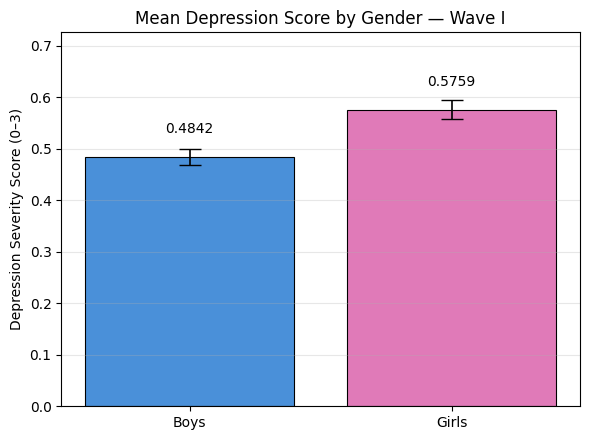

In [17]:
#  FIGURE 1 - Mean Depression Score by Gender, Wave I
fig, ax = plt.subplots(figsize=(6, 4.5))

means  = [boys_dep.mean(), girls_dep.mean()]
sems   = [boys_dep.sem(),  girls_dep.sem()]
ci95   = [1.96 * s for s in sems]

bars = ax.bar(["Boys", "Girls"], means, yerr=ci95, capsize=8,
              color=[BOY_COLOR, GIRL_COLOR], edgecolor="black", linewidth=0.8,
              error_kw={"elinewidth": 1.2, "ecolor": "black"})

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.04,
            f"{m:.4f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Depression Severity Score (0–3)")
ax.set_title("Mean Depression Score by Gender — Wave I")
ax.set_ylim(0, max(means) + 0.15)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

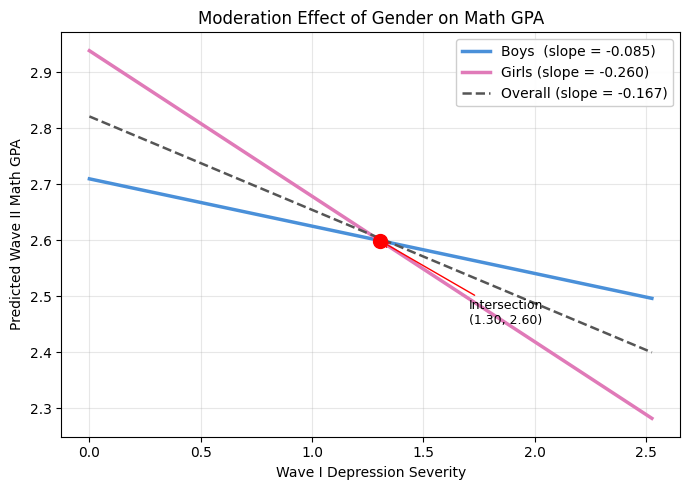

In [18]:
# FIGURE 2 — Moderation Effect of Gender on Math GPA (simple slopes)
fig, ax = plt.subplots(figsize=(7, 5))

dep_range = np.linspace(df_a["dep_w1"].min(), df_a["dep_w1"].max(), 100)
dep_c     = dep_range - dep_mean

# Predicted GPA at covariate means (already computed in main script)
gpa_boys  = int_boys  + slope_boys  * dep_c
gpa_girls = int_girls + slope_girls * dep_c

# Overall line (no gender)
overall_slope     = m2.params["dep_w1"]
overall_intercept = (m2.params["Intercept"]
                     + m2.params["ses_w1"]   * df_a["ses_w1"].mean()
                     + m2.params["se_w1"]    * df_a["se_w1"].mean()
                     + m2.params["gpa_w1"]   * df_a["gpa_w1"].mean())
gpa_overall = overall_intercept + overall_slope * dep_range

ax.plot(dep_range, gpa_boys,    color=BOY_COLOR,  linewidth=2.5, label=f"Boys  (slope = {slope_boys:.3f})")
ax.plot(dep_range, gpa_girls,   color=GIRL_COLOR, linewidth=2.5, label=f"Girls (slope = {slope_girls:.3f})")
ax.plot(dep_range, gpa_overall, color=NEUTRAL,    linewidth=1.8, linestyle="--",
        label=f"Overall (slope = {overall_slope:.3f})")

# Intersection marker
ax.plot(dep_cross_raw, gpa_cross, "o", color="red", markersize=10, zorder=5)
ax.annotate(f"Intersection\n({dep_cross_raw:.2f}, {gpa_cross:.2f})",
            xy=(dep_cross_raw, gpa_cross),
            xytext=(dep_cross_raw + 0.4, gpa_cross - 0.15),
            fontsize=9, ha="left",
            arrowprops=dict(arrowstyle="->", color="red", lw=1))

ax.set_xlabel("Wave I Depression Severity")
ax.set_ylabel("Predicted Wave II Math GPA")
ax.set_title("Moderation Effect of Gender on Math GPA")
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

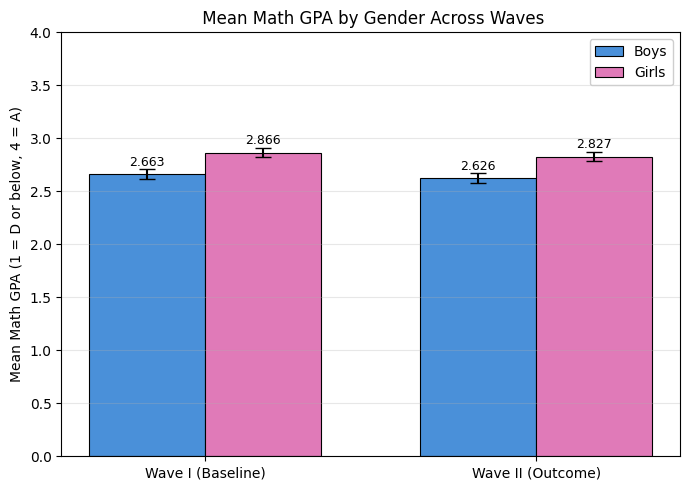

In [19]:
# FIGURE 3 — Mean Math GPA by Gender across Waves
fig, ax = plt.subplots(figsize=(7, 5))

waves   = ["Wave I (Baseline)", "Wave II (Outcome)"]
xpos    = np.arange(len(waves))
width   = 0.35

boys_w1  = df_a.loc[df_a["gender"] == 0, "gpa_w1"]
girls_w1 = df_a.loc[df_a["gender"] == 1, "gpa_w1"]
boys_w2  = df_a.loc[df_a["gender"] == 0, "gpa_w2"]
girls_w2 = df_a.loc[df_a["gender"] == 1, "gpa_w2"]

boys_means  = [boys_w1.mean(),  boys_w2.mean()]
girls_means = [girls_w1.mean(), girls_w2.mean()]
boys_err    = [1.96*boys_w1.sem(),  1.96*boys_w2.sem()]
girls_err   = [1.96*girls_w1.sem(), 1.96*girls_w2.sem()]

bars1 = ax.bar(xpos - width/2, boys_means,  width, yerr=boys_err,  capsize=6,
               color=BOY_COLOR,  label="Boys",  edgecolor="black", linewidth=0.8)
bars2 = ax.bar(xpos + width/2, girls_means, width, yerr=girls_err, capsize=6,
               color=GIRL_COLOR, label="Girls", edgecolor="black", linewidth=0.8)

# Value labels
for bar, val in zip(bars1, boys_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)
for bar, val in zip(bars2, girls_means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)

ax.set_xticks(xpos)
ax.set_xticklabels(waves)
ax.set_ylabel("Mean Math GPA (1 = D or below, 4 = A)")
ax.set_title(" Mean Math GPA by Gender Across Waves")
ax.set_ylim(0, 4)
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

